## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Quiz 4 (TEMPLATE Spring 2026)

The goal of this quiz is to give you the opportunity to test out more of the skills that you've developed thus far this semester. In particular, you'll reflect on what you know about writing code using Python and showcase some of your more recently acquired programming skills.

**Important note about using online resources**: This exam is "open internet". That means that you can look up documentation, google how to accomplish certain Python tasks, etc. Being able to effectively use the internet for computational modeling and data science is a very important skill, so we want to make sure you have the opportunity to exercise that skill. **However, the use of any person-to-person communication software is absolutely not acceptable.**

**Do your own work.** This quiz is designed to give *you* the opportunity to show the instructor what you can do and you should hold yourself accountable for maintaining a high level of academic integrity. Any violation of academic integrity could result in you receiving a zero on the quiz.

There are a total of <font color="red">**95**</font> possible on this quiz. **If you get stuck any particular question, do you your best to provide what your solution *might* look like for later parts of the exam in order to create opportunities for partial credit.**

### ANSWER (for making sure this gets removed) ###

## Template Guidelines

**Learning Objectives from Homework 4:**
* Using `solve_ivp` to solve a set of ODEs for the purposes of modeling a phenomenon
* Using `matplotlib` to visualize models
* Building compartmental models
* Interpreting model results
* Constructing clear, informative data viualizations

**Learning Objectives the Quiz will assess:**
* Solving ODEs numerically using `solve_ivp`
* Visualizing model results using `matplotlib`
* Interpreting model results from a solved set of ODEs using provided initial conditions and model parameters.
* Constructingand evaluating clear, informative data viualizations

**Learning objectives that we don't have time/space for**:

* Building a compartmental model from scratch

**Quiz Duration:** 30 minutes (ideally, time can be extended slightly if needed)
* This means your TAs/LAs should be able to complete the quiz in at most 10 minutes (if TA/LA completion time is closer to 15, consider extending quiz to 40 minutes)

**Notes:**
* The structure and rubric provided here is a suggestion and an example of the difficulty level expected. However, as long as your quiz assesses the learning objectives listed under "Learning Objectives the Quiz will assess" section above, you can differ from this structure. If you aren't sure that your quiz does that, run it by another instructor (lead isntructor, other faculty, TA, or LA)
* The examples provided are examples and **should not be used directly without changes in any quizzes**
* These quizzes are important for students to assess how well they understand the material independent of their groups, so when grading, be sure to provide feedback on where points were deducted. **You should also have a clear rubric with clearly stated point values, but you do not need to follow the point values included in this template**.
* Quizzes should be written with ample time for TAs/LAs to review! **Your TA and LAs should have at least 48 hours to review the quiz before it is given**.
* Quizzes (and instructor solution with point-by-point rubrics) should be **pushed to the GitHub repo for record-keeping**. Put your section's version in a sub-folder with the name `Section-###` where "###" is your section number.

**Overall Structure:**

1. A section that focuses on assessing if students correctly can use solve_ivp to solve an initial value program given a set of ODEs, a set of initial conditions, and a set of model parameters. Once they have a functioning solution, they should be asked to interpret their results.
2. A section that has them assess data visualizations.

---
# Academic integrity statement (10 points)

In the markdown cell below, put your personal academic integrity statement. By including this statement, you are confirming that you are submitting this as your own work and not that of someone else.


<font size=+3>&#9998;</font> *Put your personal academic integrity statement here.*

---
## Part 1: Modeling a system using `solve_ivp` (45 points)

&#9989;&nbsp; **Question 1 (25 points):** Predator–Prey Model with Harvesting

In this question, you will investigate a **predator–prey model with harvesting**, which describes how two interacting populations evolve over time.

We define:

- **X(t)**: number of prey (e.g., rabbits)  
- **Y(t)**: number of predators (e.g., foxes)  

The model is given by:

$$
\begin{aligned}
\frac{dX}{dt} &= \alpha X - \beta X Y - h X, \\
\frac{dY}{dt} &= \delta X Y - \gamma Y,
\end{aligned}
$$

where:

- $\alpha = 0.5$: prey growth rate  
- $\beta = 0.02$: predation rate  
- $\delta = 0.01$: predator reproduction rate  
- $\gamma = 0.3$: predator death rate  
- $h = 0.05$: harvesting rate of prey  

Initial conditions at $t = 0$:

- $X(0) = 40$  
- $Y(0) = 9$  

Simulate the system for **60 days** using a timestep of **$\Delta t = 0.1$** days.

---

### 🔧 Tasks

- *(5 points)* Write a function that takes in time $t$ and the current values $[X, Y]$, and returns $\frac{dX}{dt}$ and $\frac{dY}{dt}$.  
- *(5 points)* Define variables for the initial conditions.  
- *(5 points)* Create a time array using `np.arange()` that matches the given time interval and timestep.  
- *(5 points)* Use `solve_ivp` to solve the system and store the result.  
- *(3 points)* Unpack the solution and plot $X(t)$ and $Y(t)$ on the same figure.  
- *(2 points)* Briefly describe what happens to the prey population over time (e.g., does it stabilize, decrease, or oscillate?).

---

In [13]:
# The import commands you need are provided here
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

# Put your code here


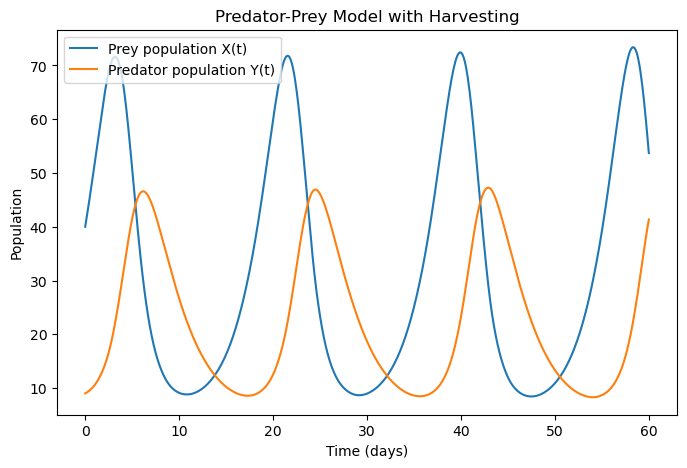

In [14]:
# Write your derivatives function here
def predator_prey_system(t, variables):
    X, Y = variables
    
    dXdt = alpha * X - beta * X * Y - h * X
    dYdt = delta * X * Y - gamma * Y
    
    return [dXdt, dYdt]
    
# Put your parameter values here
alpha = 0.5
beta = 0.02
delta = 0.01
gamma = 0.3
h = 0.05

# Set the initial conditions here
X0 = 40
Y0 = 9

initial_conditions = [X0, Y0]

# Create the time values here
t_eval = np.arange(0, 60.1, 0.1)

# Solve the system here
solution = solve_ivp(
    predator_prey_system,
    [0, 60],
    initial_conditions,
    t_eval=t_eval
)

# Unpack the solution here
t = solution.t
X = solution.y[0]
Y = solution.y[1]

#print(X)
plt.figure(figsize=(8,5))
plt.plot(t, X, label='Prey population X(t)')
plt.plot(t, Y, label='Predator population Y(t)')
plt.xlabel('Time (days)')
plt.ylabel('Population')
plt.title('Predator-Prey Model with Harvesting')
plt.legend()

plt.savefig("Quiz4_Q2.png", dpi=300)  # save BEFORE show
plt.show()
plt.close()  # optional but safer

## ✅ Question 2 (10 points)

Now that you have a solution to the model, create a single plot that displays the evolution of both populations: the prey population $X(t)$ and the predator population $Y(t)$ as functions of time.

Each line should be a different color, and your plot should include:

- an $x$-axis label  
- a $y$-axis label  
- a legend  

If all goes well, you should observe oscillatory behavior between the prey and predator populations.

![Predator-Prey Curve](Quiz4_Q2.png)

In [17]:
# put your code here

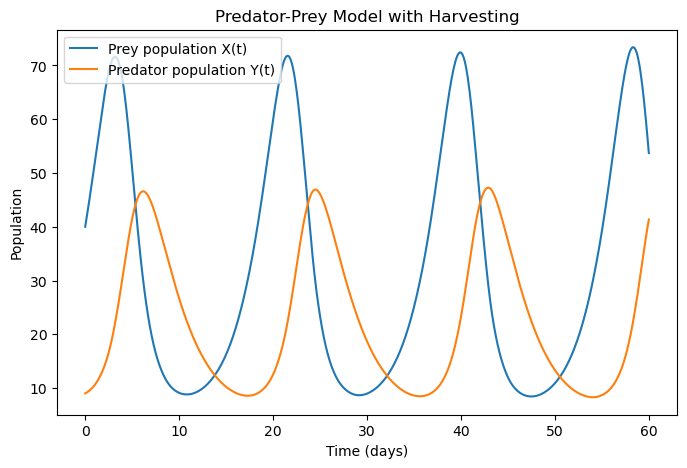

<Figure size 640x480 with 0 Axes>

In [15]:
### ANSWER ###

# Make your plot here
plt.figure(figsize=(8,5))
plt.plot(t, X, label='Prey population X(t)') # 2 points
plt.plot(t, Y, label='Predator population Y(t)')# 2 points
plt.xlabel('Time (days)')# 1 points
plt.ylabel('Population')# 1 points
plt.title('Predator-Prey Model with Harvesting')# 2 points
plt.legend()# 2 points
plt.show()

plt.savefig("Quiz4_Q2.png")

&#9989;&nbsp; **Question 3 Documenting Your Solution Pathway (10 points)**

**Answer the following questions in detail:**
1. Indicate which portions of Part 1 you answered with prior knowledge, and also indicate which portions of Part 1 you answered with the help of outside sources (e.g. generative AI, past assignments, Stack Overflow, Google, etc.) to help you? (1 point)
2. **For the parts were you DID use external resources**, document what sources you used and how they informed your approach.  If you used generative AI, be sure to include *prompts and outputs*. **For the parts where you DID NOT use external resources**, what prior knowledge did you recall to solve the problem? (4 points)
3. Does your solution work? (1 point)
4. **If your solution works**, how do you know it works?  Include any calculations you made, tests you ran, etc. **If your solution DOES NOT work**, how do you know it does not work?  What approaches would you use to verify a correct solution? (4 points)

<font size=6 color="#009600">&#9998;</font> PUT YOUR ANSWER HERE!

### ANSWER ###

RUBRIC
* 1 point indicating which portions were solved with prior knowledge and which portions were solved with outside resources
* 2 points documenting external sources usage
* 2 points indicating what prior knowledge helped
* 1 point answering if code worked
* 4 points for any well-thought out answer about how they know it does or does not work.  2 points for a superficial answer.  0 points for a blank or an answer that does not match the results

## Part 2: Data Visualization (40 points)

Below are several different data visualizations. Using what you have learned in class and in the homework about what makes a data visualization good, bad, or somewhere in between, choose **two** visualizations to assess through the following questions.

&#9989;&nbsp; **Question 1 (10 points per visualization - 20 points total)**:

Examine the visualization (and any accompanying text). In your own words, articulate your interpretation of the story the visualization is trying to convey. 

&#9989;&nbsp; **Question 2 (20 points total)**: Grade the visualization using the rubric and provide justification for your scores for each category. 

1. **Does the plot tell a story? (4 Points)** 
2. **No wasted space (2 points)**
3. **Labels, legend, and title are informative without cluttering (1 points)**
4. **Presenting multi-variable data (1 points)**

### Visualizations to Choose From


**Visualization 1**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/AISentiment.jpg?raw=true">

**Visualization 2**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/Screenshot 2023-11-29 at 4.32.57 PM.png?raw=true">

**Visualization 3**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/VisualCapitalist_Copper.jpg?raw=true">

**Visualization 4**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (7).png?raw=true">

**Visualization 5**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (2).png?raw=true">

**Visualization 6**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (6).png?raw=true">

**Visualization 7**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/image (9).png?raw=true">

**Visualization 8**
<img src="https://github.com/msu-cmse-courses/cmse201-supplemental/blob/main/bad_data_viz/whimsical_squid.png?raw=true">

### ANSWER ###

Instructors feel free to pull from [this folder](https://michiganstate-my.sharepoint.com/:f:/g/personal/salmonra_msu_edu/Ev2JG0xB3VlJrHSpxyWYNegBbLrgss7lOHlTJOP2kUBwtQ?e=nloeSF) of bad visualizations and add your favorite bad visualizations!



**QUESTION 1 RESPONSES HERE**

**QUESTION 2 RESPONSES HERE**